                       DT        DN        HT        HN
Feature                                                
detail                0.0  0.042789  0.028971  0.000000
r_directionality      0.0  0.007437  0.000000  0.046536
theta_directionality  0.0  0.005960  0.000000  0.043304
brightness            0.0  0.010382  0.000000  0.011863
contrast              0.0  0.002496  0.000000  0.004171


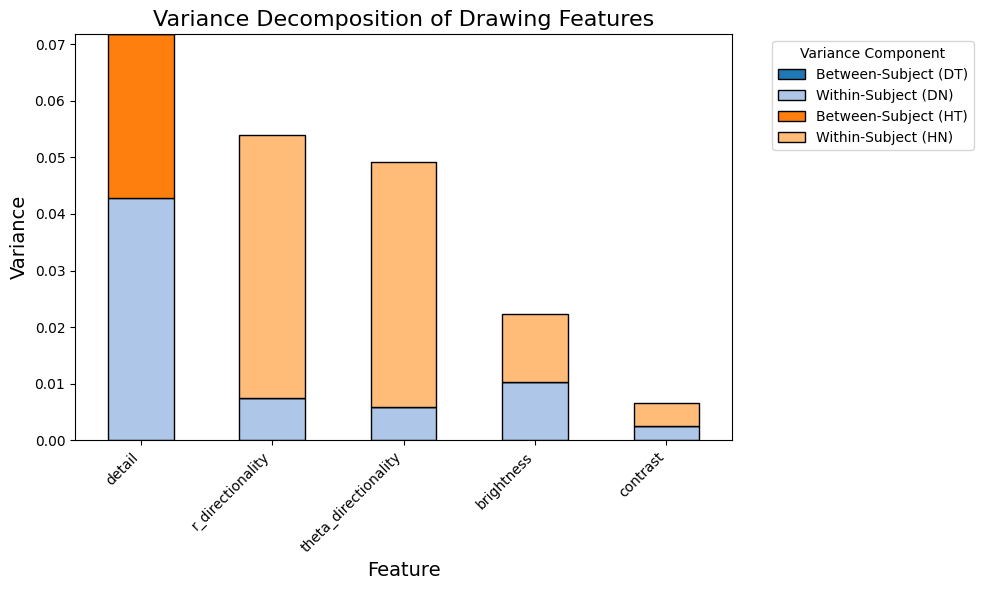

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load extracted variances
df_val = pd.read_csv("../015_tables/validation_variances.csv")
df_exp = pd.read_csv("../015_tables/experimental_variances.csv")

df_combined = pd.merge(df_val, df_exp, on='Feature')

# Compute target variances, clipping at 0 to handle instances where validation noise exceeds experimental noise
df_combined['HT'] = (df_combined['DT_plus_HT'] - df_combined['DT']).clip(lower=0)
df_combined['HN'] = (df_combined['DN_plus_HN'] - df_combined['DN']).clip(lower=0)

df_plot = df_combined[['Feature', 'DT', 'DN', 'HT', 'HN']].set_index('Feature')
df_plot.to_csv("../015_tables/variance_decomposition.csv")
print(df_plot)

# Render Stacked Bar
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78'] 

df_plot.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black')

ax.set_title('Variance Decomposition of Drawing Features', fontsize=16)
ax.set_ylabel('Variance', fontsize=14)
ax.set_xlabel('Feature', fontsize=14)
ax.legend(['Between-Subject (DT)', 'Within-Subject (DN)', 'Between-Subject (HT)', 'Within-Subject (HN)'], 
          title='Variance Component', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save
os.makedirs("../020_visualizations", exist_ok=True)
plt.savefig("../020_visualizations/variance_decomposition.png", dpi=300, bbox_inches='tight')
plt.show()

--- Assumption Tests ---

[FAILED] Experimental Noise < Validation Noise for:
  - detail: Exp(0.035395) < Val(0.042789)

[PASSED] Experimental Traits >= Validation Traits for all features.
------------------------



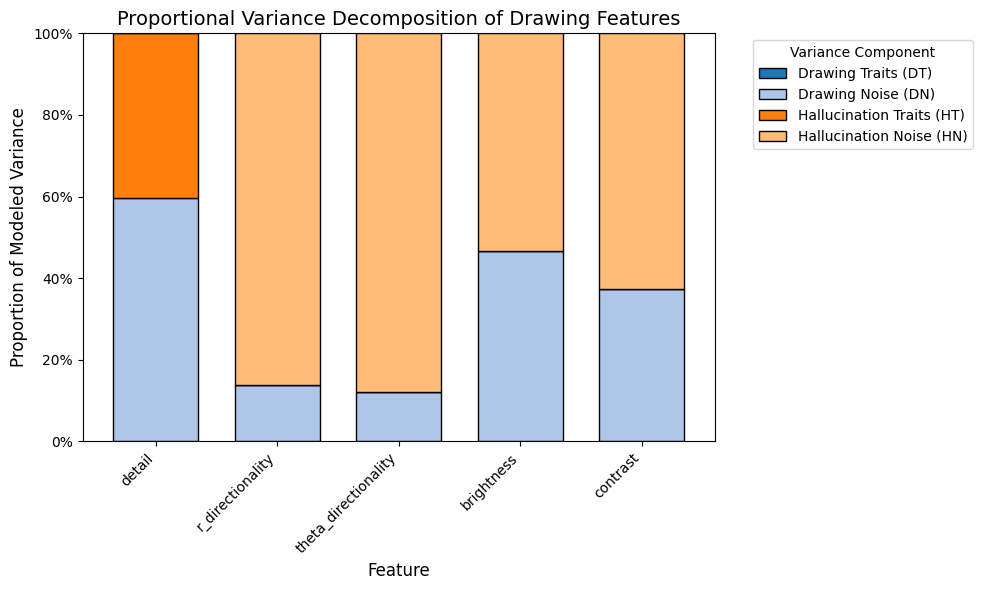

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Load Data
df_val = pd.read_csv("../015_tables/validation_variances.csv")
df_exp = pd.read_csv("../015_tables/experimental_variances.csv")

# 2. Merge Data
df_combined = pd.merge(df_val, df_exp, on='Feature')

# 3. Explicit Assumption Tests
print("--- Assumption Tests ---")
# Test 1: Experimental Noise >= Validation Noise
df_combined['Noise_Diff'] = df_combined['DN_plus_HN'] - df_combined['DN']
failed_noise = df_combined[df_combined['Noise_Diff'] < 0]

if not failed_noise.empty:
    print("\n[FAILED] Experimental Noise < Validation Noise for:")
    for _, row in failed_noise.iterrows():
        print(f"  - {row['Feature']}: Exp({row['DN_plus_HN']:.6f}) < Val({row['DN']:.6f})")
else:
    print("\n[PASSED] Experimental Noise >= Validation Noise for all features.")

# Test 2: Experimental Traits >= Validation Traits
df_combined['Trait_Diff'] = df_combined['DT_plus_HT'] - df_combined['DT']
failed_trait = df_combined[df_combined['Trait_Diff'] < 0]

if not failed_trait.empty:
    print("\n[FAILED] Experimental Traits < Validation Traits for:")
    for _, row in failed_trait.iterrows():
        print(f"  - {row['Feature']}: Exp({row['DT_plus_HT']:.6f}) < Val({row['DT']:.6f})")
else:
    print("\n[PASSED] Experimental Traits >= Validation Traits for all features.")
print("------------------------\n")

# 4. Calculate Final Variances (Clipping to 0 for visualization purposes)
df_combined['HT'] = df_combined['Trait_Diff'].clip(lower=0)
df_combined['HN'] = df_combined['Noise_Diff'].clip(lower=0)

df_variances = df_combined[['Feature', 'DT', 'DN', 'HT', 'HN']].copy()

# 5. Convert to Proportions (Ratios)
df_variances['Total_Var'] = df_variances['DT'] + df_variances['DN'] + df_variances['HT'] + df_variances['HN']

for col in ['DT', 'DN', 'HT', 'HN']:
    df_variances[f'{col}_prop'] = df_variances[col] / df_variances['Total_Var']

df_plot = df_variances[['Feature', 'DT_prop', 'DN_prop', 'HT_prop', 'HN_prop']].set_index('Feature')
df_variances.to_csv("../015_tables/variance_decomposition.csv", index=False)

# 6. Visualize (100% Stacked Bar Chart)
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78'] 
df_plot.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', width=0.7)

ax.set_title('Proportional Variance Decomposition of Drawing Features', fontsize=14)
ax.set_ylabel('Proportion of Modeled Variance', fontsize=12)
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylim(0, 1)

# Format y-axis as percentages
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

ax.legend(['Drawing Traits (DT)', 'Drawing Noise (DN)', 'Hallucination Traits (HT)', 'Hallucination Noise (HN)'], 
          title='Variance Component', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

os.makedirs("../020_visualizations", exist_ok=True)
plt.savefig("../020_visualizations/variance_decomposition_ratio.png", dpi=300, bbox_inches='tight')
plt.show()